In [2]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import random
from dreal import *
import matplotlib.patches as patches
from matplotlib import cm

In [3]:

torch.cuda.empty_cache()
torch.manual_seed(17)
random.seed()


In [4]:

device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Pre-allocate numerical_x
numerical_x = torch.Tensor(500, 2).uniform_(-6, 6).float().to(device)


Using device: cpu


# Van der pol oscillator

The contorlled version of van der pol oscillator is:
\begin{align}
    \dot{x}_1&=x_2\\
    \dot{x}_2&=\mu(1-x_1^2)x_2-x_1+u
\end{align}

In [5]:

# Physical constants for inverted pendulum
damping_factor = 0.1

In [6]:
def f(x):
    """Vectorized Van der Pol dynamics f(x) - handles batched input"""
    if x.dim() == 1:
        x = x.unsqueeze(0)
    
    val = torch.stack(
        [
        x[:, 1],
        damping_factor * (1 - x[:, 0]**2) * x[:, 1] - x[:, 0]
    ], dim=1
    )
    
    return val.squeeze(0) if val.shape[0] == 1 else val


def g(x):
    """Vectorized g(x) - handles batched input"""
    if x.dim() == 1:
        x = x.unsqueeze(0)
    
    val = torch.stack([
        torch.zeros_like(x[:, 0]),
        torch.full_like(x[:, 0], 1.0)
    ], dim=1)
    
    return val.squeeze(0) if val.shape[0] == 1 else val

def div_f(x):
    """Vectorized divergence of f - handles batched input: div(f)= damping * (1-x[0]^2)"""
    if x.dim() == 1:
        return damping_factor * (1 - x[0]**2)
    else:
        return damping_factor * ( 1- x[:, 0]**2)
    

def div_g(x):
    """Vectorized divergence of g"""
    if x.dim() == 1:
        return torch.tensor(0.0, device=device)
    else:
        return torch.zeros(x.shape[0], device=device)

In [7]:

class polynomial_net(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(polynomial_net, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, output_dim)
        )
        self._initialize_weights()

    def _initialize_weights(self):
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward(self, x):
        return self.net(x)

class polynomial_net_bias_Zero(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(polynomial_net_bias_Zero, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),       
            nn.Linear(hidden_dim, output_dim)
        )
        self._initialize_weights()

    def _initialize_weights(self):
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)
                layer.bias.requires_grad = False
                

    def forward(self, x):
        return self.net(x)
                

class numerator_polynomial_net(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(numerator_polynomial_net, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Sigmoid(),
            nn.Linear(hidden_dim, output_dim),
            nn.Sigmoid()
        )
        self._initialize_weights()

    def _initialize_weights(self):
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward(self, x):
        return self.net(x)

class GammaFunctionNet(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(GammaFunctionNet, self).__init__()
        self.linear_layer = nn.Linear(input_dim, output_dim)
        nn.init.constant_(self.linear_layer.weight, 0)
        nn.init.constant_(self.linear_layer.bias, 0)
        self.linear_layer.weight.requires_grad = False

    def forward(self, x):
        if x.dim() == 1:
            return abs(self.linear_layer.bias)
        return abs(self.linear_layer.bias.expand(x.shape[0], -1))

In [8]:

def gradient_batch(func, x):
    """Compute gradients for a batch of inputs efficiently"""
    x = x.clone().detach().requires_grad_(True)
    output = func(x).sum()
    grad = torch.autograd.grad(outputs=output, inputs=x, create_graph=True)[0]
    return grad

def gradient_batch_special_b(func, x):
    """Compute gradients of ||f(x)||^2 for a batch efficiently"""
    x = x.clone().detach().requires_grad_(True)
    output = func(x)
    output_norm_squared = (output ** 2).sum(dim=1).sum()
    grad = torch.autograd.grad(outputs=output_norm_squared, inputs=x, create_graph=True)[0]
    return grad

# ==================== FULLY VECTORIZED CONTROL DENSITY ====================

def control_density_risk_vectorized(x, f_fun, g_fun, a_fun, b_fun, c_fun):
    """FULLY VECTORIZED - processes entire batch at once"""
    batch_size = x.shape[0]
    
    # Compute all values in batch
    divergence_at_f = div_f(x)  # [batch_size]
    divergence_at_g = div_g(x)  # [batch_size]
    
    # Compute gradients for entire batch
    grad_at_a = gradient_batch(a_fun, x)  # [batch_size, 2]
    grad_at_c = gradient_batch(c_fun, x)  # [batch_size, 2]
    grad_at_b = gradient_batch_special_b(b_fun, x)  # [batch_size, 2]
    
    # Compute function values
    a_vals = a_fun(x).squeeze()  # [batch_size]
    c_vals = c_fun(x).squeeze()  # [batch_size]
    f_vals = f(x)  # [batch_size, 2]
    g_vals = g(x)  # [batch_size, 2]
    
    # Vectorized computation of term1
    term1 = (a_vals * divergence_at_f + 
             divergence_at_g * c_vals + 
             (grad_at_a * f_vals).sum(dim=1) + 
             (grad_at_c * g_vals).sum(dim=1))
    
    # Vectorized computation of term2
    scaled_x = 2 * x + grad_at_b  # [batch_size, 2]
    combined = f_vals * a_vals.unsqueeze(1) + g_vals * c_vals.unsqueeze(1)  # [batch_size, 2]
    term2 = (scaled_x * combined).sum(dim=1)
    
    return term1 - term2

def control_density_loss(x, f_fun, g_fun, a_fun, b_fun, c_fun, gamma_fun):
    """Optimized loss computation"""
    divergence = control_density_risk_vectorized(x, f_fun, g_fun, a_fun, b_fun, c_fun)
    gamma_vals = gamma_fun(x).squeeze()
    
    loss = F.relu(gamma_vals - divergence).mean()
    a_loss = F.relu( - a_fun(x)).mean()
    gamma_loss = F.relu(-gamma_vals).mean()
    
    return loss + a_loss + gamma_loss

In [60]:

def checkSMTconstraints(vars, a_learnt, divergence_learnt, ball_lb, ball_ub, config, epsilon=0):
    """Check the SMT constraints for the given variables and learnt parameters"""
    ball = Expression(0)
    
    for i in range(len(vars)):
        ball += vars[i]**2
    ball_in_bound = logical_and(ball >= ball_lb, ball <= ball_ub)
    
    a_condition = a_learnt >= 0
    divergence_condition = divergence_learnt > 0
    stability_condition = logical_and(
        logical_imply(ball_in_bound, divergence_condition),
        logical_imply(ball_in_bound, a_condition)
    )
    
    return CheckSatisfiability(logical_not(stability_condition), config)

def AddCounterexamples(x, CE, N, device):
    """Adds counterexamples to the sample set efficiently"""
    nearby = []
    for i in range(CE.size()):
        lb = CE[i].lb()
        ub = CE[i].ub()
        nearby_ = np.random.uniform(lb, ub, N)
        nearby.append(nearby_)
    
    # Vectorized counterexample addition
    new_points = np.column_stack(nearby)
    new_points_tensor = torch.tensor(new_points, dtype=torch.float32, device=device)
    x = torch.cat((x, new_points_tensor), dim=0)
    x = torch.unique(x, dim=0)
    
    return x, new_points_tensor

# ==================== SYMBOLIC NN CLASSES ====================

class SymbolicNN:
    """Convert neural networks to symbolic expressions for dReal"""
    def __init__(self, net):
        self.weights = []
        self.biases = []
        self.extract_params(net)

    def extract_params(self, net):
        for layer in net.net:
            if isinstance(layer, nn.Linear):
                self.weights.append(layer.weight.detach().cpu().numpy())
                if layer.bias is not None:
                    self.biases.append(layer.bias.detach().cpu().numpy())

    def forward_symbolic(self, vars):
        z = vars
        for i in range(len(self.weights) - 1):
            z = self._linear_symbolic(z, self.weights[i], self.biases[i])
            z = [tanh(zi) for zi in z]
        z = self._linear_symbolic(z, self.weights[-1], self.biases[-1])
        return z

    def _linear_symbolic(self, x, weight, bias):
        out = []
        for i in range(weight.shape[0]):
            expr = bias[i]
            for j in range(weight.shape[1]):
                expr += weight[i,j] * x[j]
            out.append(expr)
        return out

class activSymbolicNN:
    """Convert neural networks with sigmoid to symbolic expressions"""
    def __init__(self, net):
        self.weights = []
        self.biases = []
        self.extract_params(net)

    def extract_params(self, net):
        for layer in net.net:
            if isinstance(layer, nn.Linear):
                self.weights.append(layer.weight.detach().cpu().numpy())
                if layer.bias is not None:
                    self.biases.append(layer.bias.detach().cpu().numpy())

    def forward_symbolic(self, vars):
        z = vars
        for i in range(len(self.weights)):
            z = self._linear_symbolic(z, self.weights[i], self.biases[i])
            z = [(1/(1 + exp(-zi))) for zi in z]
        return z

    def _linear_symbolic(self, x, weight, bias):
        out = []
        for i in range(weight.shape[0]):
            expr = bias[i]
            for j in range(weight.shape[1]):
                expr += weight[i,j] * x[j]
            out.append(expr)
        return out

def candidate_constraint_learnt(vars, a_fun, b_fun, c_fun):
    """Construct candidate constraints for the learnt functions"""
    a_sym = activSymbolicNN(a_fun).forward_symbolic(vars)[0]
    b_sym = SymbolicNN(b_fun).forward_symbolic(vars)
    c_sym = SymbolicNN(c_fun).forward_symbolic(vars)[0]
    
    b_sym = sum([bi**2 for bi in b_sym])
    
    # Symbolic dynamics for inverted pendulum
    f_val = [
        vars[1],
        damping_factor * (1 - vars[0]**2) * vars[1] - vars[0]
    ]
    g_val = [
        0.0 * vars[0],
        1.0 
    ]
    
    f_div = damping_factor * (1 - vars[0]**2)
    g_div = 0
    
    grad_a = [a_sym.Differentiate(vars[i]) for i in range(len(vars))]
    grad_c = [c_sym.Differentiate(vars[i]) for i in range(len(vars))]
    grad_b = [b_sym.Differentiate(vars[i]) for i in range(len(vars))]
    
    constraint1 = (a_sym * f_div + g_div * c_sym + 
                   sum([grad_a[i] * f_val[i] for i in range(len(f_val))]) + 
                   sum([grad_c[i] * g_val[i] for i in range(len(g_val))]))
    
    scaled_vars = [2 * var_i for var_i in vars]
    constraint2 = [scaled_vars[i] + grad_b[i] for i in range(len(vars))]
    constraint2 = sum([constraint2[i] * (f_val[i] * a_sym + g_val[i] * c_sym) 
                      for i in range(len(f_val))])
    
    constraint = constraint1 - constraint2
    return a_sym, constraint


In [61]:

def train_density(x, epochs=2000, lr=1e-2, ball_lb=0.5, ball_ub=2, check_interval=10):
    """Train density function with SMT-based counterexample refinement"""
    loss_total_density = []
    

    a_net = numerator_polynomial_net(2,8, 1).to(device)
    c_net = polynomial_net(2, 12, 1).to(device)
    b_net = polynomial_net_bias_Zero(2,8, 2).to(device)
    gamma_net = GammaFunctionNet(2, 1).to(device)
    
    optimizer = torch.optim.Adam(
        list(a_net.parameters()) + list(c_net.parameters()) + 
        list(b_net.parameters()) + list(gamma_net.parameters()), 
        lr=lr
    )
    
    # Configure dReal SMT solver
    config = Config()
    config.use_polytope_in_forall = True
    config.use_local_optimization = True
    config.precision = 1e-5
    
    valid = False
    print("Training density function with SMT verification")
    print(f"Initial dataset size: {x.shape[0]}")
    
    while not valid:
        for epoch in range(epochs):
            optimizer.zero_grad()
            loss = control_density_loss(x, f, g, a_net, b_net, c_net, gamma_net)
            loss_total_density.append(loss.item())
            loss.backward()
            optimizer.step()
            
            if loss.item() < 5e-4:
                print(f"  [Epoch {epoch}] Loss reached zero!")
                valid = True
                break
            
            if epoch % 50 == 0:
                print(f"Epoch {epoch}/{epochs}, Loss: {loss.item():.4f}, Dataset size: {x.shape[0]}")
            
            # Check for counterexamples periodically
            if epoch % check_interval == 0 and epoch > 0:
                print(f"  [Epoch {epoch}] Checking SMT constraints...")
                vars = [Variable("x1"), Variable("x2")]
                
                try:
                    a_learnt, divergence_learnt = candidate_constraint_learnt(vars, a_net, b_net, c_net)
                    CE = checkSMTconstraints(vars, a_learnt, divergence_learnt, ball_lb, ball_ub, config)
                    
                    if CE:
                        print(f" Counterexample found! Adding 100 new points...")
                        x_before = x.shape[0]
                        x, n_pt_tensor = AddCounterexamples(x, CE, 100, device)
                        x_after = x.shape[0]
                        print(f"  Dataset size: {x_before} → {x_after} (+{x_after - x_before} unique)")
                    else:
                        valid = True
                        print(" No counterexample found - constraints satisfied!")
                        break
                except Exception as e:
                    print(f"   SMT check failed: {e}")
                    continue
        
        # if not valid:
        #     print("Training loop completed without validation. Checking final constraints...")
        #     vars = [Variable("x1"), Variable("x2")]
        #     try:
        #         a_learnt, divergence_learnt = candidate_constraint_learnt(vars, a_net, b_net, c_net)
        #         CE = checkSMTconstraints(vars, a_learnt, divergence_learnt, ball_lb, ball_ub, config)
        #         if not CE:
        #             valid = True
        #             print("Final check passed!")
        #         else:
        #             print(" Final check found counterexamples, but continuing...")
        #             valid = True
        #     except:
        #         valid = True
    
    print(f"\nTraining completed!")
    print(f"Final Loss: {loss.item():.4f}")
    test_point = torch.tensor([[0, 0]], dtype=torch.float32, device=device)
    print(f"The learned margin is {gamma_net(test_point).item():.6f}")
    print(f"Final dataset size: {x.shape[0]}")
    
    return loss_total_density, a_net, b_net, c_net, gamma_net


In [62]:

def plot_results(risks, labels):
    """Plot risk curves"""
    plt.figure(figsize=(10, 6))
    for risk, label in zip(risks, labels):
        plt.plot(risk, label=label)
    plt.xlabel("Iteration")
    plt.ylabel("Risk")
    plt.title("Risk Over Iterations")
    plt.legend()
    plt.grid()
    plt.show()


def plot_density_contours(a_nn, b_nn, c_nn,density_threshold, device, plot_flow=True):
    """Plot density contours with optional flow field"""
    x1 = torch.linspace(-6, 6, 100)
    x2 = torch.linspace(-6, 6, 100)
    X, Y = np.meshgrid(x1.cpu().numpy(), x2.cpu().numpy())
    
    grid_points = torch.tensor(np.column_stack([X.ravel(), Y.ravel()]), 
                               dtype=torch.float32).to(device)
    
    with torch.no_grad():
        rho_set = a_nn(grid_points) / (torch.exp(
            torch.sum(grid_points**2, dim=1, keepdim=True) + 
            torch.sum((b_nn(grid_points))**2, dim=1, keepdim=True)
        ))
        rho_set = rho_set.squeeze().cpu().numpy().reshape(X.shape)
    
    fig, ax = plt.subplots(figsize=(8, 6))

    
    ax.contour(X,Y,rho_set-density_threshold,levels=0,colors='black', linewidths=2,linestyles='solid', label='Density')

    filled_contours = ax.contourf(X, Y, rho_set, levels=10, alpha=0.3, cmap=cm.coolwarm)
    plt.colorbar(filled_contours, label='Density Value')
    
    if plot_flow:
        x1_flow = np.linspace(-6, 6, 20)
        x2_flow = np.linspace(-6, 6, 20)
        X_flow, Y_flow = np.meshgrid(x1_flow, x2_flow)
        flow_points = torch.tensor(np.column_stack([X_flow.ravel(), Y_flow.ravel()]), 
                                   dtype=torch.float32).to(device)
        
        with torch.no_grad():
            u_values = (c_nn(flow_points) / (a_nn(flow_points) + 1e-9)).squeeze()
        
        DX = np.zeros_like(X_flow)
        DY = np.zeros_like(Y_flow)
        
        for i in range(len(x1_flow)):
            for j in range(len(x2_flow)):
                idx = i * len(x1_flow) + j
                x = torch.tensor([X_flow[i, j], Y_flow[i, j]], device=device)
                f_val = f(x)
                g_val = g(x)
                u = u_values[idx]
                
                flow = f_val + g_val * u
                DX[i, j] = flow[0].cpu().numpy()
                DY[i, j] = flow[1].cpu().numpy()
        
        magnitude = np.sqrt(DX**2 + DY**2) + 1e-9
        DX = DX / magnitude
        DY = DY / magnitude
        # magnitudex = np.sqrt(DX**2)
        # magnitudey = np.sqrt(DY**2 )
        # DX_norm = DX / magnitudex
        # DY_norm = DY / magnitudey
        
        ax.streamplot(X_flow, Y_flow, DX, DY, color='gray', linewidth=0.5,
                     density=1.0, arrowstyle='-|>', arrowsize=1.5)
    
    circle = plt.Circle((0, 0), 6, color='r', fill=False, 
                        linewidth=1.5, label='Valid Region')
    ax.add_artist(circle)
    
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.set_title('Density Function Contours with Flow Field')
    ax.legend()
    ax.grid(True)
    plt.show()
    
    return fig, ax


In [63]:
print("=" * 60)
print("Van der Pol Oscillator")
print("=" * 60)

# Train the density function
loss_density, a_ret, b_ret, c_ret, gamma_net = train_density(
    numerical_x, epochs=4000, lr=1e-4, ball_lb=0.5, ball_ub=6, check_interval=1500
)


Van der Pol Oscillator
Training density function with SMT verification
Initial dataset size: 500
Epoch 0/4000, Loss: 0.0087, Dataset size: 500
Epoch 50/4000, Loss: 0.0040, Dataset size: 500
Epoch 100/4000, Loss: 0.0024, Dataset size: 500
Epoch 150/4000, Loss: 0.0018, Dataset size: 500
Epoch 200/4000, Loss: 0.0015, Dataset size: 500
Epoch 250/4000, Loss: 0.0013, Dataset size: 500
Epoch 300/4000, Loss: 0.0012, Dataset size: 500
Epoch 350/4000, Loss: 0.0011, Dataset size: 500
Epoch 400/4000, Loss: 0.0009, Dataset size: 500
Epoch 450/4000, Loss: 0.0009, Dataset size: 500
Epoch 500/4000, Loss: 0.0008, Dataset size: 500
Epoch 550/4000, Loss: 0.0008, Dataset size: 500
Epoch 600/4000, Loss: 0.0007, Dataset size: 500
Epoch 650/4000, Loss: 0.0007, Dataset size: 500
Epoch 700/4000, Loss: 0.0007, Dataset size: 500
Epoch 750/4000, Loss: 0.0007, Dataset size: 500
Epoch 800/4000, Loss: 0.0006, Dataset size: 500
Epoch 850/4000, Loss: 0.0006, Dataset size: 500
Epoch 900/4000, Loss: 0.0006, Dataset size


Plotting loss curve...


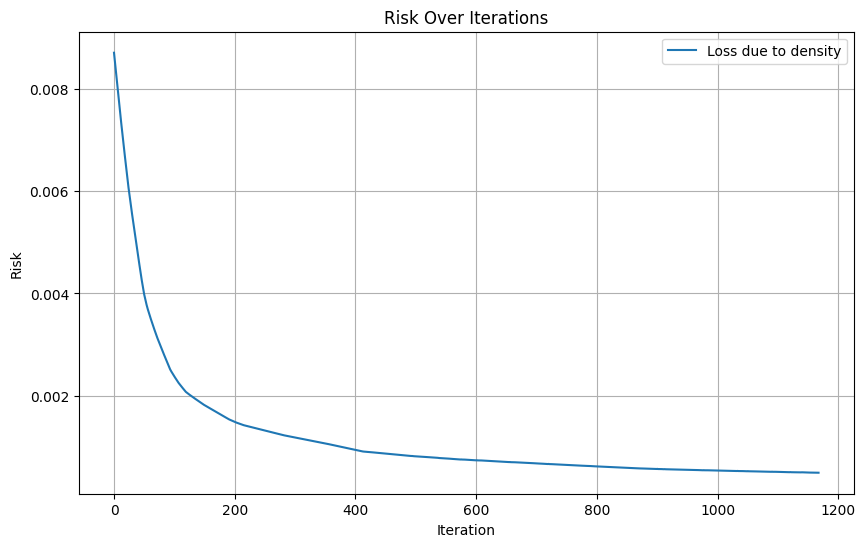

In [64]:

# Plot loss curve
print("\nPlotting loss curve...")
risks = [loss_density]
plot_results(risks, labels=['Loss due to density'])



Generating density visualization...


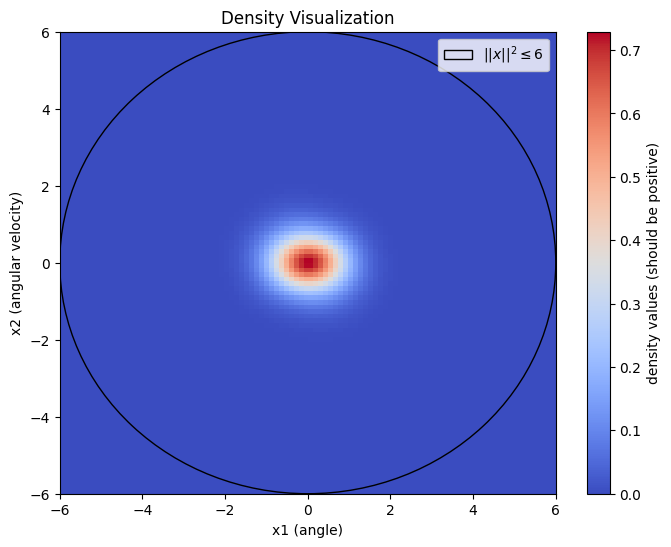

In [65]:

# Visualize density
print("\nGenerating density visualization...")
grid_size = 100
x1 = torch.linspace(-6, 6, grid_size)
x2 = torch.linspace(-6, 6, grid_size)
x1_grid, x2_grid = torch.meshgrid(x1, x2, indexing='ij')
grid_points = torch.stack([x1_grid.ravel(), x2_grid.ravel()], dim=1).to(device)

with torch.no_grad():
    rho_set = a_ret(grid_points) / (torch.exp(
        torch.sum(grid_points**2, dim=1, keepdim=True) + 
        torch.sum((b_ret(grid_points))**2, dim=1, keepdim=True)
    ))

violations_set = rho_set.detach().cpu().numpy().reshape(grid_size, grid_size)

plt.figure(figsize=(8, 6))
plt.imshow(violations_set, extent=[-6, 6, -6, 6], origin='lower',
            cmap='coolwarm', aspect='auto')
plt.colorbar(label="density values (should be positive)")
plt.xlabel("x1 (angle)")
plt.ylabel("x2 (angular velocity)")
plt.title("Density Visualization")
circle = patches.Circle((0, 0), 6, color='black', fill=False, 
                        linewidth=1, label="$||x||^2 \\leq 6$")
plt.gca().add_patch(circle)
plt.legend(loc='upper right')
plt.grid(False)
plt.show()



Generating divergence visualization...


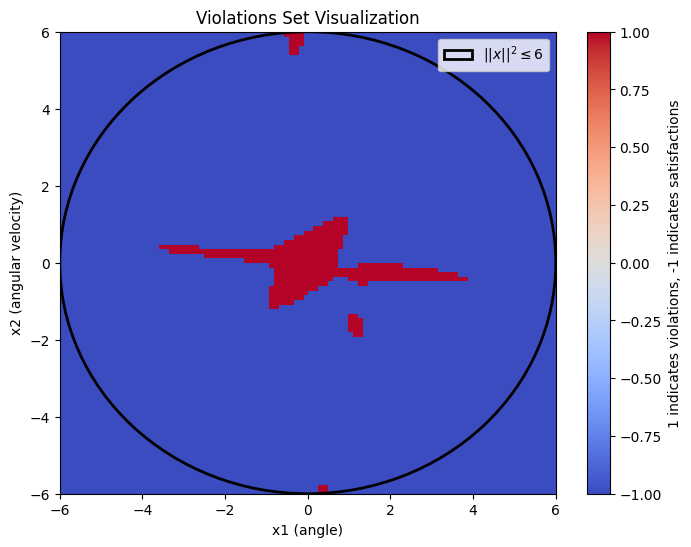

In [66]:

# Visualize divergence/violations
print("\nGenerating divergence visualization...")
# Note: control_density_risk_vectorized needs gradients, so we don't use no_grad here
divergence_set = control_density_risk_vectorized(grid_points, f, g, a_ret, b_ret, c_ret)

violations_set = torch.where(divergence_set <= 0, 1, -1)
violations_set = violations_set.detach().cpu().numpy().reshape(grid_size, grid_size)

plt.figure(figsize=(8, 6))
plt.imshow(violations_set, extent=[-6, 6, -6, 6], origin='lower',
            cmap='coolwarm', aspect='auto')
plt.colorbar(label="1 indicates violations, -1 indicates satisfactions")
plt.xlabel("x1 (angle)")
plt.ylabel("x2 (angular velocity)")
plt.title("Violations Set Visualization")
circle = patches.Circle((0, 0), 6, color='black', fill=False, 
                        linewidth=2, label="$||x||^2 \\leq 6$")
plt.gca().add_patch(circle)
plt.legend(loc='upper right')
plt.grid(False)
plt.show()


Plotting density contours with flow field...


/tmp/ipykernel_282864/765536495.py:33: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(X,Y,rho_set-density_threshold,levels=0,colors='black', linewidths=2,linestyles='solid', label='Density')


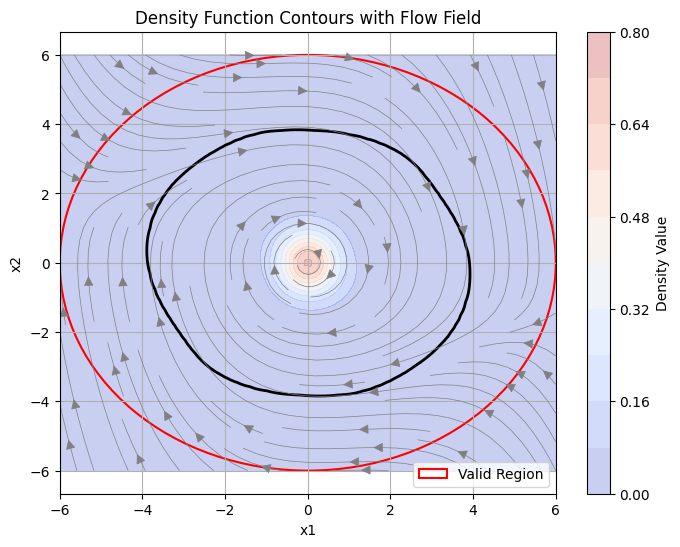


EXPERIMENT COMPLETED!


In [67]:


# Plot density contours with flow field
print("\nPlotting density contours with flow field...")
plot_density_contours(a_ret, b_ret, c_ret,5e-8, device, plot_flow=True)

print("\n" + "=" * 60)
print("EXPERIMENT COMPLETED!")
print("=" * 60)

In [68]:
# save the models
torch.save(a_ret.state_dict(), 'vander_pol_a_net.pth')
torch.save(b_ret.state_dict(), 'vander_pol_b_net.pth')
torch.save(c_ret.state_dict(), 'vander_pol_c_net.pth')

Training density function with SMT verification
Initial dataset size: 500
Epoch 0/4000, Loss: 0.2139, Dataset size: 500
Epoch 50/4000, Loss: 0.1843, Dataset size: 500
Epoch 100/4000, Loss: 0.1566, Dataset size: 500
Epoch 150/4000, Loss: 0.1312, Dataset size: 500
Epoch 200/4000, Loss: 0.1088, Dataset size: 500
Epoch 250/4000, Loss: 0.0883, Dataset size: 500
Epoch 300/4000, Loss: 0.0703, Dataset size: 500
Epoch 350/4000, Loss: 0.0533, Dataset size: 500
Epoch 400/4000, Loss: 0.0379, Dataset size: 500
Epoch 450/4000, Loss: 0.0240, Dataset size: 500
Epoch 500/4000, Loss: 0.0178, Dataset size: 500
Epoch 550/4000, Loss: 0.0142, Dataset size: 500
Epoch 600/4000, Loss: 0.0122, Dataset size: 500
Epoch 650/4000, Loss: 0.0109, Dataset size: 500
Epoch 700/4000, Loss: 0.0098, Dataset size: 500
Epoch 750/4000, Loss: 0.0088, Dataset size: 500
Epoch 800/4000, Loss: 0.0079, Dataset size: 500
Epoch 850/4000, Loss: 0.0071, Dataset size: 500
Epoch 900/4000, Loss: 0.0064, Dataset size: 500
Epoch 950/4000, L

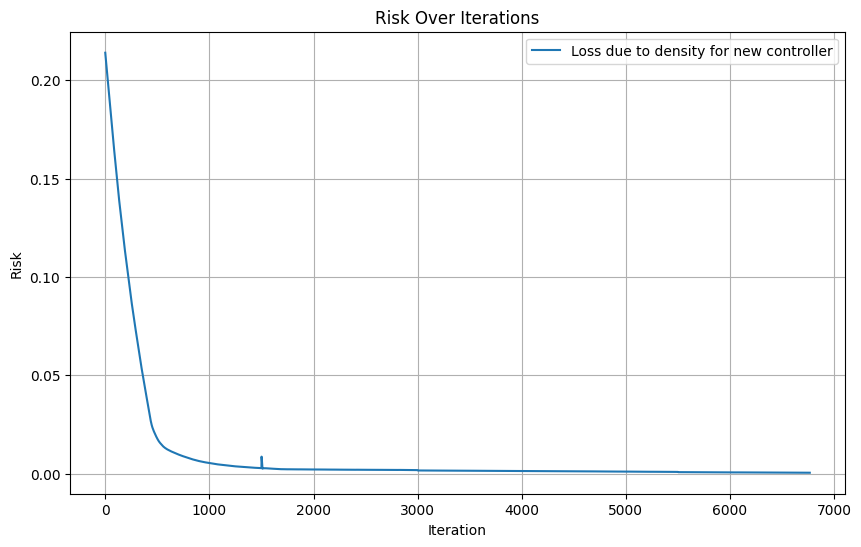

In [69]:
torch.manual_seed(2004)
random.seed()

# learn a new controller with new sets of data

numerical_x = torch.Tensor(500, 2).uniform_(-6, 6).float().to(device)

loss_density1, a_ret1, b_ret1, c_ret1, gamma_net1 = train_density(
    numerical_x, epochs=4000, lr=1e-4, ball_lb=0.5, ball_ub=6, check_interval=1500
)

# Plot loss curve
print("\nPlotting loss curve for new controller...")
risks = [loss_density1]
plot_results(risks, labels=['Loss due to density for new controller'])


Generating density visualization...


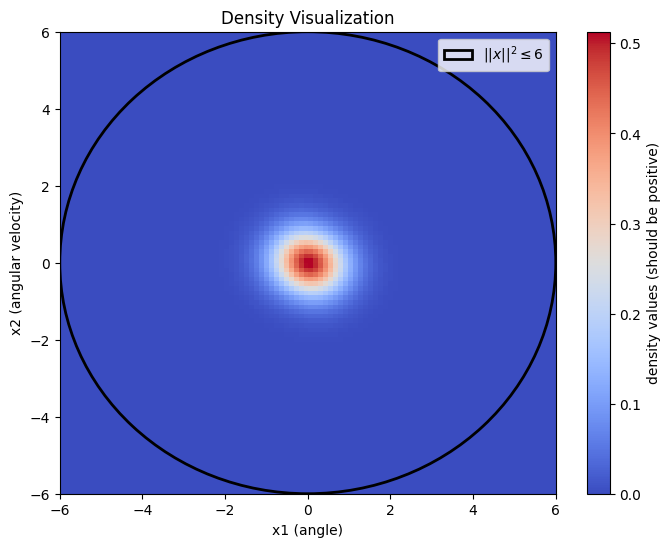

In [70]:

# Visualize density
print("\nGenerating density visualization...")
grid_size = 100
x1 = torch.linspace(-6, 6, grid_size)
x2 = torch.linspace(-6, 6, grid_size)
x1_grid, x2_grid = torch.meshgrid(x1, x2, indexing='ij')
grid_points = torch.stack([x1_grid.ravel(), x2_grid.ravel()], dim=1).to(device)

with torch.no_grad():
    rho_set = a_ret1(grid_points) / (torch.exp(
        torch.sum(grid_points**2, dim=1, keepdim=True) + 
        torch.sum((b_ret1(grid_points))**2, dim=1, keepdim=True)
    ))

violations_set = rho_set.detach().cpu().numpy().reshape(grid_size, grid_size)

plt.figure(figsize=(8, 6))
plt.imshow(violations_set, extent=[-6, 6, -6, 6], origin='lower',
            cmap='coolwarm', aspect='auto')
plt.colorbar(label="density values (should be positive)")
plt.xlabel("x1 (angle)")
plt.ylabel("x2 (angular velocity)")
plt.title("Density Visualization")
circle = patches.Circle((0, 0), 6, color='black', fill=False, 
                        linewidth=2, label="$||x||^2 \\leq 6$")
plt.gca().add_patch(circle)
plt.legend(loc='upper right')
plt.grid(False)
plt.show()



Generating divergence visualization...


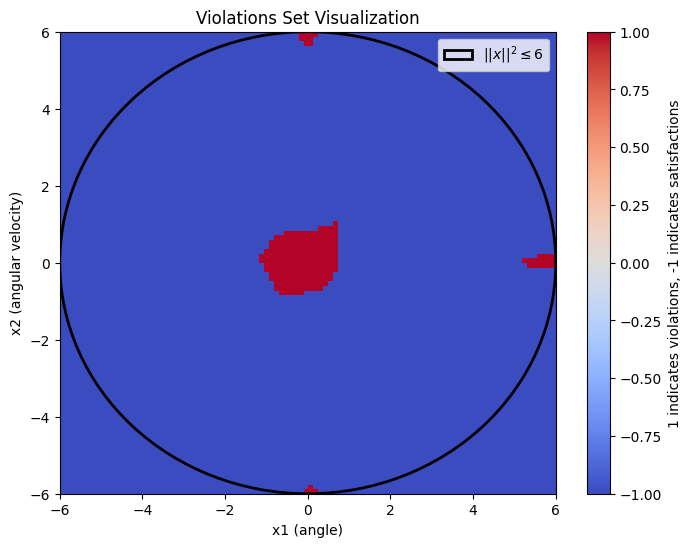

In [71]:

# Visualize divergence/violations
print("\nGenerating divergence visualization...")
# Note: control_density_risk_vectorized needs gradients, so we don't use no_grad here
divergence_set = control_density_risk_vectorized(grid_points, f, g, a_ret1, b_ret1, c_ret1)

violations_set = torch.where(divergence_set <= 0, 1, -1)
violations_set = violations_set.detach().cpu().numpy().reshape(grid_size, grid_size)

plt.figure(figsize=(8, 6))
plt.imshow(violations_set, extent=[-6, 6, -6, 6], origin='lower',
            cmap='coolwarm', aspect='auto')
plt.colorbar(label="1 indicates violations, -1 indicates satisfactions")
plt.xlabel("x1 (angle)")
plt.ylabel("x2 (angular velocity)")
plt.title("Violations Set Visualization")
circle = patches.Circle((0, 0), 6, color='black', fill=False, 
                        linewidth=2, label="$||x||^2 \\leq 6$")
plt.gca().add_patch(circle)
plt.legend(loc='upper right')
plt.grid(False)
plt.show()


Plotting density contours with flow field for new controller...


/tmp/ipykernel_282864/765536495.py:33: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(X,Y,rho_set-density_threshold,levels=0,colors='black', linewidths=2,linestyles='solid', label='Density')


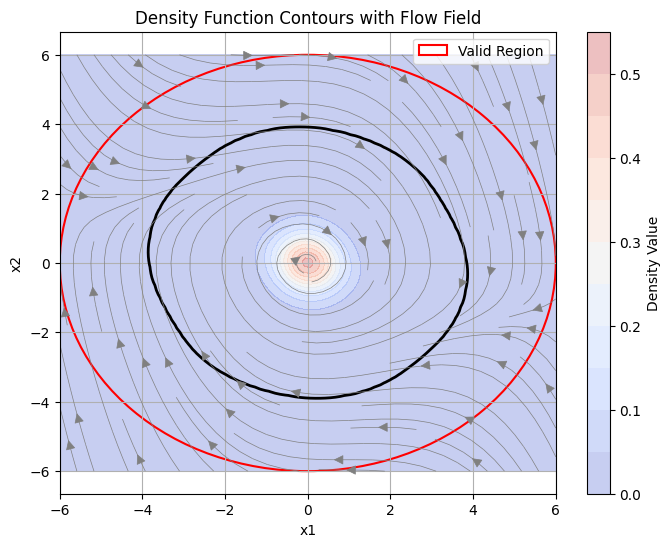

In [72]:
print("\nPlotting density contours with flow field for new controller...")
plot_density_contours(a_ret1, b_ret1, c_ret1,5e-8, device, plot_flow=True)
print("\n" + "=" * 60)

In [73]:
# save the models
torch.save(a_ret1.state_dict(), 'vander_pol_a_net1.pth')
torch.save(b_ret1.state_dict(), 'vander_pol_b_net1.pth')
torch.save(c_ret1.state_dict(), 'vander_pol_c_net1.pth')

In [9]:
INPUT_DIM = 2
HIDDEN_DIM_A = 8
HIDDEN_DIM_B = 8
HIDDEN_DIM_C = 12
OUTPUT_DIM_B = 2

# LOAD THE MODELS
a_net = numerator_polynomial_net(INPUT_DIM, HIDDEN_DIM_A, 1).to(device)
a_net.load_state_dict(torch.load('Model_Paths/vander_pol_a_net.pth', map_location=device))
b_net = polynomial_net_bias_Zero(INPUT_DIM, HIDDEN_DIM_B, OUTPUT_DIM_B).to(device)
b_net.load_state_dict(torch.load('Model_Paths/vander_pol_b_net.pth', map_location=device))
c_net = polynomial_net(INPUT_DIM, HIDDEN_DIM_C, 1).to(device)
c_net.load_state_dict(torch.load('Model_Paths/vander_pol_c_net.pth', map_location=device))

a_net1 = numerator_polynomial_net(INPUT_DIM, HIDDEN_DIM_A, 1).to(device)
a_net1.load_state_dict(torch.load('Model_Paths/vander_pol_a_net1.pth', map_location=device))
b_net1 = polynomial_net_bias_Zero(INPUT_DIM, HIDDEN_DIM_B, OUTPUT_DIM_B).to(device)
b_net1.load_state_dict(torch.load('Model_Paths/vander_pol_b_net1.pth', map_location=device))
c_net1 = polynomial_net(INPUT_DIM, HIDDEN_DIM_C, 1).to(device)
c_net1.load_state_dict(torch.load('Model_Paths/vander_pol_c_net1.pth', map_location=device))

print("Models loaded successfully.")
a_net.eval()
b_net.eval()
c_net.eval()
a_net1.eval()
b_net1.eval()
c_net1.eval()

Models loaded successfully.


/tmp/ipykernel_3515/2027472658.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  a_net.load_state_dict(torch.load('Model_Paths/vander_pol_a_net.pth', map_location=device))

polynomial_net(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=12, bias=True)
    (1): Tanh()
    (2): Linear(in_features=12, out_features=1, bias=True)
  )
)

/tmp/ipykernel_3515/1357013915.py:20: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(X,Y,rho_set-density_threshold,levels=0,colors='black', linewidths=2,linestyles='solid', label='Mixed Density')


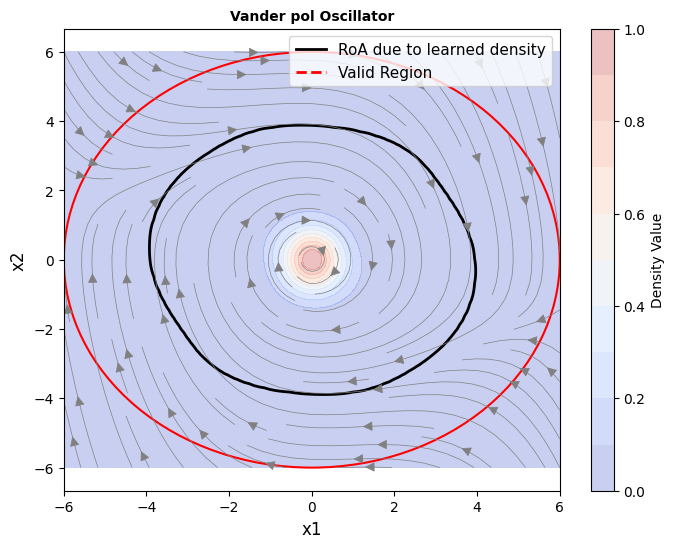

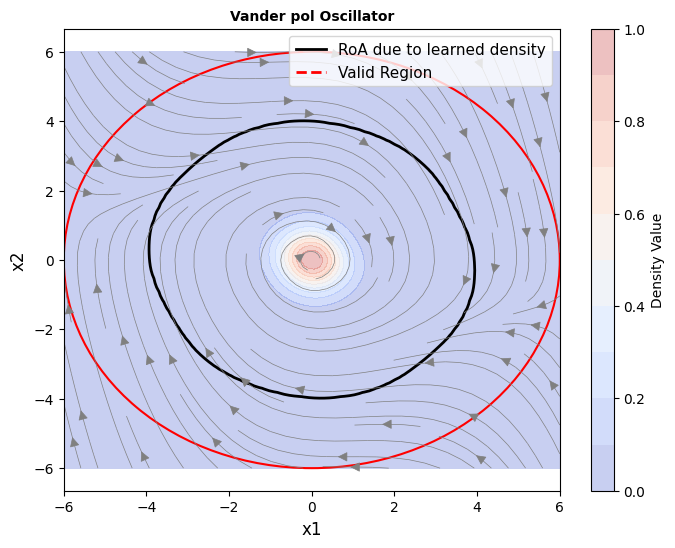

(<Figure size 800x600 with 2 Axes>,
 <Axes: title={'center': 'Vander pol Oscillator'}, xlabel='x1', ylabel='x2'>)

In [10]:
def plot_density_countours(a_nn, b_nn, c_nn,density_threshold, device, plot_flow=True):
    # create meshgrid
    x1 = torch.linspace(-6, 6, 100)
    x2 = torch.linspace(-6, 6, 100)
    X, Y = np.meshgrid(x1,x2)

    # Convert to torch tensor
    grid_points = torch.tensor(np.column_stack([X.ravel(), Y.ravel()]), dtype=torch.float32).to(device)

    # compute the modified density function
    with torch.no_grad():
        rho_set = a_nn(grid_points) / (torch.exp( torch.sum(grid_points**2, dim=1, keepdim=True) + torch.sum((b_nn(grid_points))**2, dim=1, keepdim=True)))
        rho_set = rho_set / max(rho_set)
        rho_set = rho_set.squeeze()
        rho_set = rho_set.cpu().numpy().reshape(X.shape)
    # plot the density function
    fig, ax = plt.subplots(figsize=(8, 6))
    # contours = ax.contour(X, Y, rho_set, levels=10, colors='k')

    ax.contour(X,Y,rho_set-density_threshold,levels=0,colors='black', linewidths=2,linestyles='solid', label='Mixed Density')

    filled_contours = ax.contourf(X, Y, rho_set, levels=10, alpha=0.3, cmap=cm.coolwarm)
    plt.colorbar(filled_contours, label='Density Value')

    if plot_flow:
        # create coarser grid for flow field
        x1_flow = np.linspace(-6, 6, 20)
        x2_flow = np.linspace(-6, 6, 20)
        X_flow, Y_flow = np.meshgrid(x1_flow, x2_flow)
        flow_points = torch.tensor(np.column_stack([X_flow.ravel(), Y_flow.ravel()]), dtype=torch.float32).to(device)

        # evaluate control policy u
        with torch.no_grad():
            u_values = c_nn(flow_points) / a_nn(flow_points)
               
        # Calculate vector field
        DX = np.zeros_like(X_flow)
        DY = np.zeros_like(Y_flow)
        
        for i in range(len(x1_flow)):
            for j in range(len(x2_flow)):
                idx = i * len(x1_flow) + j
                x = torch.tensor([X_flow[i, j], Y_flow[i, j]], device=device)
                f_val = f(x)
                g_val = g(x)
                u = u_values[idx]
                
                # Compute flow: f(x) + g(x)u
                flow = f_val + g_val * u
                DX[i, j] = flow[0].cpu().numpy()
                DY[i, j] = flow[1].cpu().numpy()
        
        # Normalize vectors for better visualization
        magnitude = np.sqrt(DX**2 + DY**2)
        DX = DX / magnitude
        DY = DY / magnitude
        
        # Plot flow field
        ax.streamplot(X_flow, Y_flow, DX, DY, color='gray', linewidth=0.5,
                     density=1.0, arrowstyle='-|>', arrowsize=1.5)
    
    # Add valid region circle
    circle = plt.Circle((0, 0), 6, color='r', fill=False, linewidth=1.5, label='Valid Region')
    ax.add_artist(circle)
    
    # Customize plot
    ax.set_xlabel('x1', fontsize=12)
    ax.set_ylabel('x2', fontsize=12)
    ax.set_title('Vander pol Oscillator', fontsize=10, fontweight='bold')
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='black', linewidth=2, linestyle='-', label='RoA due to learned density'),
        Line2D([0], [0], color='red', linewidth=2, linestyle='--', label='Valid Region')
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=11)
    
    
    
    plt.show()
    
    return fig, ax

# Call the function to plot density contours and flow field
plot_density_countours(a_net, b_net, c_net,5e-8, device, plot_flow=True)


# Call the function to plot density contours and flow field
plot_density_countours(a_net1, b_net1, c_net1,5e-8, device, plot_flow=True)





    

/tmp/ipykernel_3515/1098309981.py:23: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(X, Y, rho_set1, levels=[density_threshold], colors='blue', linewidths=2, linestyles='dashed', label='Density 1')
/tmp/ipykernel_3515/1098309981.py:24: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(X, Y, rho_set2, levels=[density_threshold], colors='green', linewidths=2, linestyles='dashed', label='Density 2')
/tmp/ipykernel_3515/1098309981.py:25: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(X,Y,rho_set,levels=[density_threshold],colors='black', linewidths=2,linestyles='solid', label='Mixed Density')


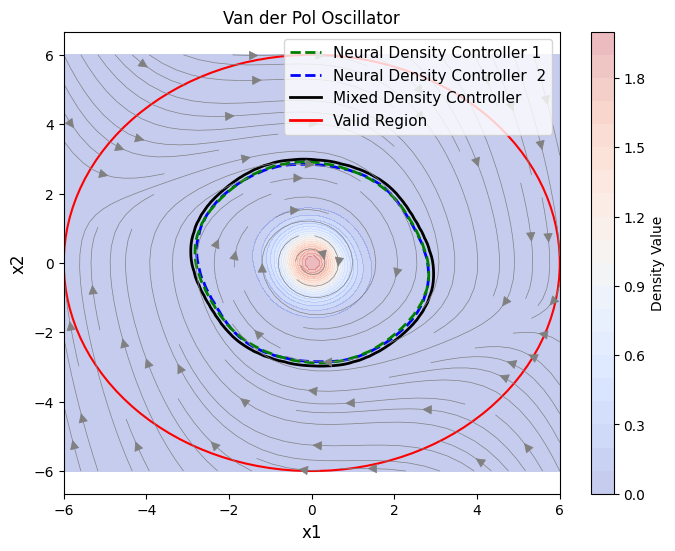

(<Figure size 800x600 with 2 Axes>,
 <Axes: title={'center': 'Van der Pol Oscillator'}, xlabel='x1', ylabel='x2'>)

In [11]:
def plot_mixed_density_countours(a_nn, b_nn, c_nn,a_nn1,b_nn1,c_nn1, density_threshold, device, plot_flow=True):
    # create meshgrid
    x1 = torch.linspace(-6, 6, 100)
    x2 = torch.linspace(-6, 6, 100)
    X, Y = np.meshgrid(x1,x2)

    # Convert to torch tensor
    grid_points = torch.tensor(np.column_stack([X.ravel(), Y.ravel()]), dtype=torch.float32).to(device)

    # compute the modified density function
    with torch.no_grad():
        rho_set1 = a_nn(grid_points) / (torch.exp( torch.sum(grid_points**2, dim=1, keepdim=True) + torch.sum((b_nn(grid_points))**2, dim=1, keepdim=True)))
        rho_set2 = a_nn1(grid_points) / (torch.exp( torch.sum(grid_points**2, dim=1, keepdim=True) + torch.sum((b_nn1(grid_points))**2, dim=1, keepdim=True)))
        rho_set1 = rho_set1 / max(rho_set1)
        rho_set2 = rho_set2 / max(rho_set2)
        rho_set =  rho_set1+rho_set2
        rho_set = rho_set.squeeze()
        rho_set = rho_set.cpu().numpy().reshape(X.shape)
        rho_set1 = rho_set1.squeeze().cpu().numpy().reshape(X.shape)
        rho_set2 = rho_set2.squeeze().cpu().numpy().reshape(X.shape)
    # plot the density function
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.contour(X, Y, rho_set1, levels=[density_threshold], colors='blue', linewidths=2, linestyles='dashed', label='Density 1')
    ax.contour(X, Y, rho_set2, levels=[density_threshold], colors='green', linewidths=2, linestyles='dashed', label='Density 2')
    ax.contour(X,Y,rho_set,levels=[density_threshold],colors='black', linewidths=2,linestyles='solid', label='Mixed Density')
    filled_contours = ax.contourf(X, Y, rho_set, levels=20, alpha=0.3, cmap=cm.coolwarm)
    plt.colorbar(filled_contours, label='Density Value')

    if plot_flow:
        # create coarser grid for flow field
        x1_flow = np.linspace(-6, 6, 80)
        x2_flow = np.linspace(-6, 6, 80)
        X_flow, Y_flow = np.meshgrid(x1_flow, x2_flow)
        flow_points = torch.tensor(np.column_stack([X_flow.ravel(), Y_flow.ravel()]), dtype=torch.float32).to(device)

        # evaluate control policy u
        with torch.no_grad():
            rho_set1 = a_nn(flow_points) / (torch.exp( torch.sum(flow_points**2, dim=1, keepdim=True) + torch.sum((b_nn(flow_points))**2, dim=1, keepdim=True)))
            rho_set2 = a_nn1(flow_points) / (torch.exp( torch.sum(flow_points**2, dim=1, keepdim=True) + torch.sum((b_nn1(flow_points))**2, dim=1, keepdim=True)))
            u_values1 = c_nn(flow_points) / a_nn(flow_points)
            u_values2 = c_nn1(flow_points) / a_nn1(flow_points)
            rho_set1 = rho_set1 / max(rho_set1)
            rho_set2 = rho_set2 / max(rho_set2)
            weight1 = rho_set1 / (rho_set1+rho_set2)
            weight2 = rho_set2 / (rho_set1+rho_set2)
            u_values = weight1 * u_values1 + weight2 * u_values2
               
        # Calculate vector field
        DX = np.zeros_like(X_flow)
        DY = np.zeros_like(Y_flow)
        
        for i in range(len(x1_flow)):
            for j in range(len(x2_flow)):
                idx = i * len(x1_flow) + j
                x = torch.tensor([X_flow[i, j], Y_flow[i, j]], device=device)
                f_val = f(x)
                g_val = g(x)
                u = u_values[idx]
                
                # Compute flow: f(x) + g(x)u
                flow = f_val + g_val * u
                DX[i, j] = flow[0].cpu().numpy()
                DY[i, j] = flow[1].cpu().numpy()
        
        # Normalize vectors for better visualization
        magnitude = np.sqrt(DX**2 + DY**2)
        DX = DX / magnitude
        DY = DY / magnitude
        
        # Plot flow field
        ax.streamplot(X_flow, Y_flow, DX, DY, color='gray', linewidth=0.5,
                     density=1.0, arrowstyle='-|>', arrowsize=1.5)
    
    # Add valid region circle
    circle = plt.Circle((0, 0), 6, color='r', fill=False, linewidth=1.5, label='Valid Region')
    ax.add_artist(circle)
    
    # Customize plot
    ax.set_xlabel('x1', fontsize=12)
    ax.set_ylabel('x2', fontsize=12)
    ax.set_title('Van der Pol Oscillator', fontsize=12)
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='green', linewidth=2, linestyle='--', label='Neural Density Controller 1'),
        Line2D([0], [0], color='blue', linewidth=2, linestyle='--', label='Neural Density Controller  2'),
        Line2D([0], [0], color='black', linewidth=2, linestyle='-', label='Mixed Density Controller'),
        Line2D([0], [0], color='red', linewidth=2, linestyle='-', label='Valid Region')
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=11)
    
    
   
    
    plt.show()
    
    return fig, ax


# Call the function to plot density contours and flow field
plot_mixed_density_countours(a_net, b_net, c_net,a_net1,b_net1,c_net1, 1e-4, device, plot_flow=True)

